In [1]:
import matplotlib.pyplot as plt
import numpy as np
from nilearn.image import get_data, load_img, math_img
from nilearn.plotting import plot_stat_map

%load_ext autoreload
%autoreload 2
from survey_medley_code.config_loader import load_config
from survey_medley_code.pairwise_conjunction_aggregation import (
    get_p_t_maps,
    process_pairwise_maps,
)

# Reviewing the Results

This notebook shows the Omnibus F-test maps for questionnaire averages adjusted for character length and behavior response
Note that the inputs for the models I ran here were from models of the question-specific activations.  That model (one level lower than this)
included an idicator for each questionnaire, a centered behavioral response variable and character length.  I don't believe character length was centered, 
therefore we cannot look at mean activations for each questionnaire.  It doesn't matter here as every comparison is between pairs of questionnaires.

## Omnibus F-test
The Omnibus F-test detects whether there is any difference among the group means at a voxel level.

- Results are shown for both corrected questionnaire average activation estimates.
- Thresholding uses **TFCE p < 0.05**.
- A significant F indicates that some effect exists in the voxel, but does **not** specify which pairs differ.
- It can be significant even if none of the individual pre-defined pairwise contrasts reach the threshold — for example, when small, distributed differences combine to yield a significant F.

## Pairwise T-tests
Pairwise T-tests examine specific differences between two conditions/contrasts.


## Pairwise T-test Conjunction Results
These maps examine **all possible conjunctions** of positive and negative significant results across the 10 pairwise comparisons.

- Individual paired comparisons are thresholded at **TFCE p < 0.05**.
- For conjunction maps containing at least one cluster of >400 voxels, the maps are overlaid on the Omnibus F-test map:
  - **Yellow** = F-test only  
  - **Blue** = Conjunction only  
  - **Green** = Both F-test and conjunction

## Notebook Layout
1. **Omnibus F-test results**  
2. **Individual Pairwise t-tests**
2. **Relating paired T-test conjunctions to Omnibus F results**


In [2]:
cfg = load_config()
mask_path = (
    cfg.output_root / 'assess_subject_bold_dropout/group_mask_intersection_30pct.nii.gz'
)

In [3]:
outdir = cfg.output_root / 'within_subject_unified_model'


In [4]:
omnibus_pmap_file = outdir / 'group_f_test/glm_tfce_corrp_fstat1.nii.gz'
omnibus_fmap_file = outdir / 'group_f_test/glm_fstat1.nii.gz'

paired_outdir = outdir / 'all_paired_t_tests'


In [5]:
omnibus_pmap_file.exists(), omnibus_fmap_file.exists(), paired_outdir.exists()

(True, True, True)

### Quick peek at lower level models for a couple of subjects



In [6]:
import pandas as pd
from nilearn.plotting import plot_design_matrix

outdir_win_sub_mods = outdir / 'within_subject_results'

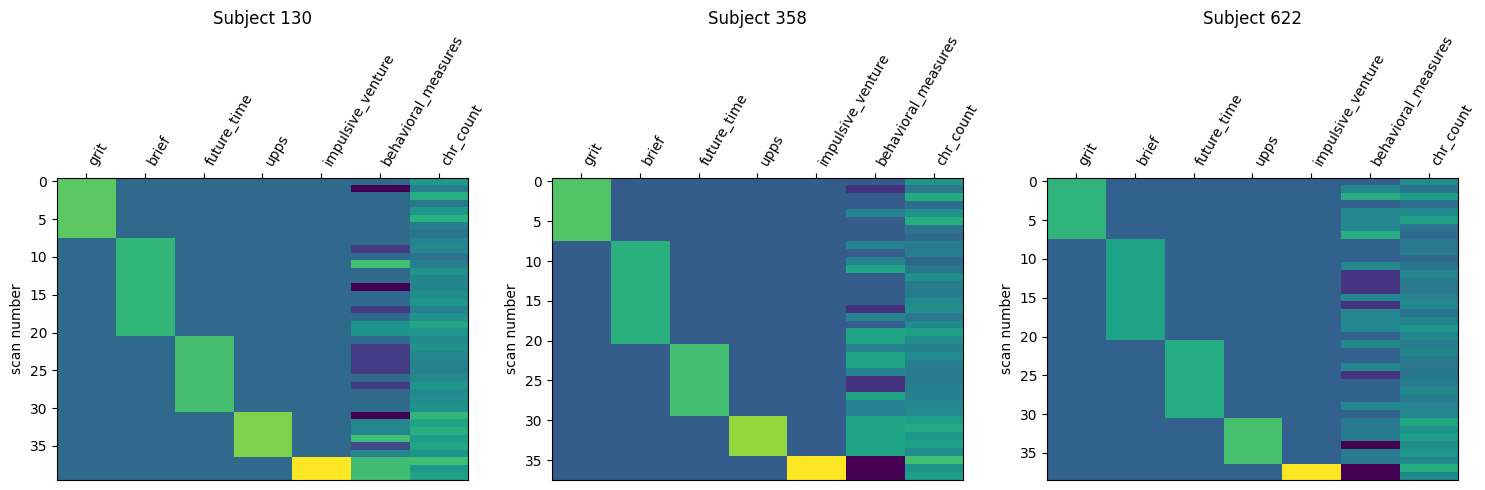

In [7]:
sub_ids_to_check = ['130', '358', '622']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, sub_id in zip(axes, sub_ids_to_check):
    desmat_file = outdir_win_sub_mods / sub_id / 'design_matrix.csv'
    assert desmat_file.exists(), f'Design matrix file not found for subject {sub_id}'

    desmat = pd.read_csv(desmat_file)

    plot_design_matrix(desmat, axes=ax)
    ax.set_title(f'Subject {sub_id}')

plt.tight_layout()
plt.show()

## 1. Omnibus F-test results

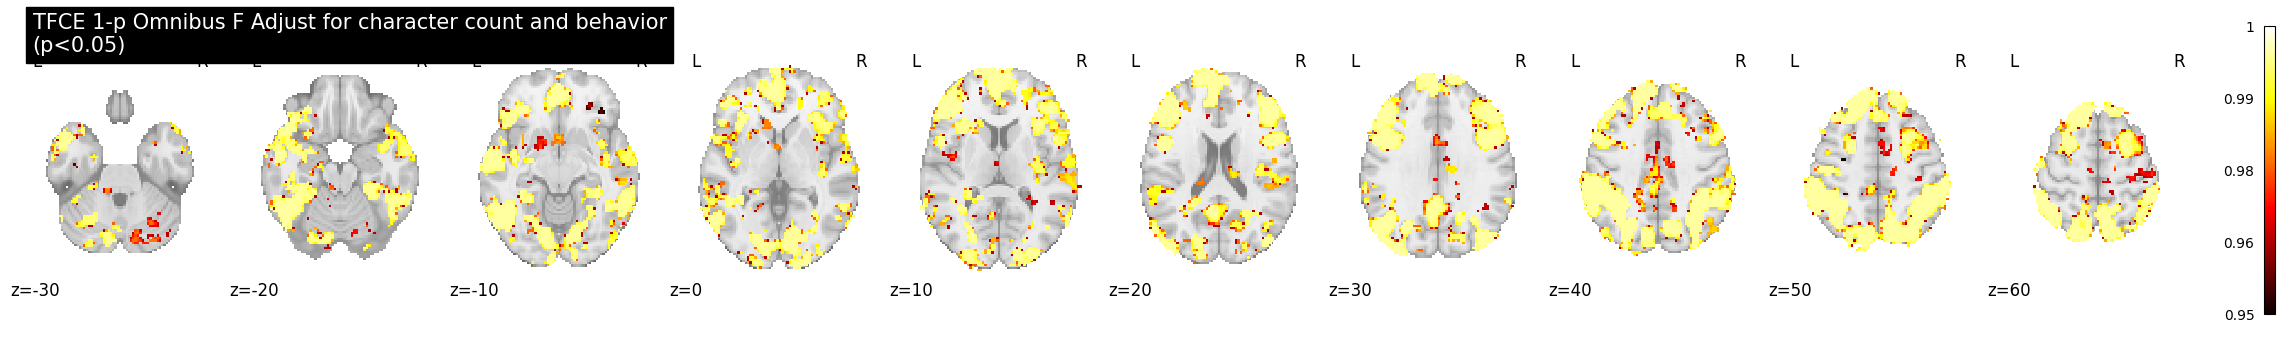

In [8]:
z_slices = list(range(-30, 61, 10))
threshold = 0.95

plot_stat_map(
    omnibus_pmap_file,
    threshold=threshold,
    display_mode='z',
    cut_coords=z_slices,
    colorbar=True,
    vmin=0.95,
    vmax=1.005,
    symmetric_cbar=False,
    cmap='hot',
    title=f'TFCE 1-p Omnibus F Adjust for character count and behavior\n(p<{(1 - threshold):.2f})',
)
plt.show()

## 2. All pairwise comparisons
I've used a Bonferroni correction across the 10 tests.

In [9]:
question_pmaps, question_tmaps = get_p_t_maps(paired_outdir)


/tmp/ipykernel_27146/3918633191.py:20: UserWarning: empty mask
  display = plot_stat_map(


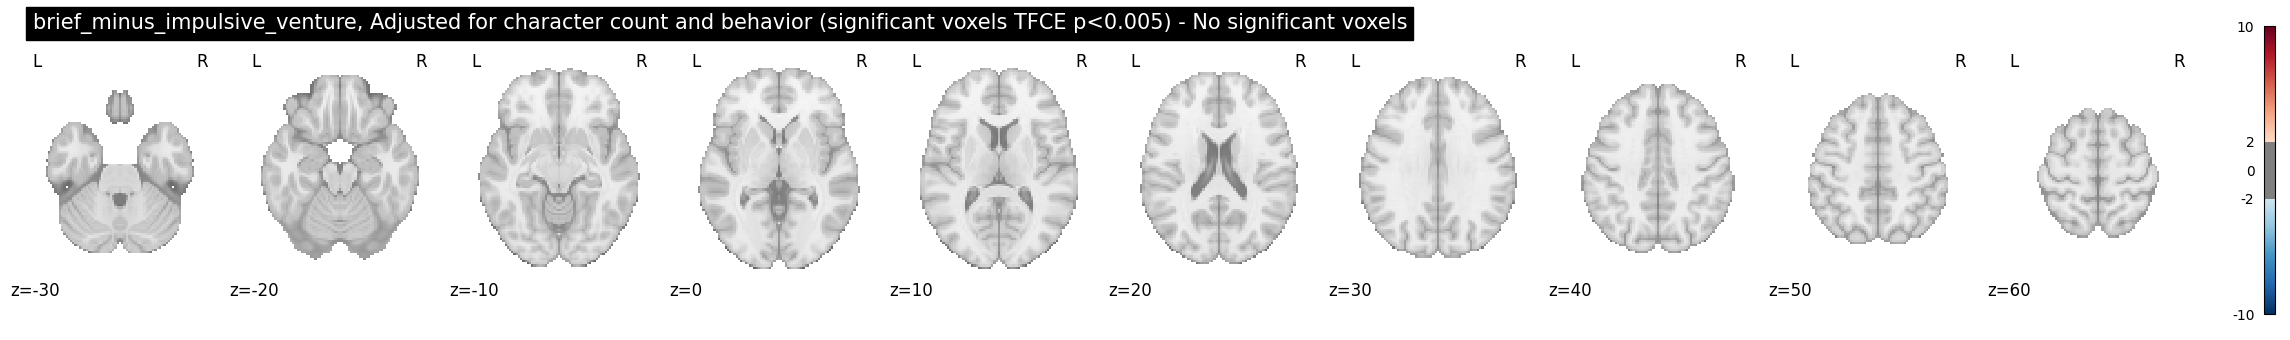

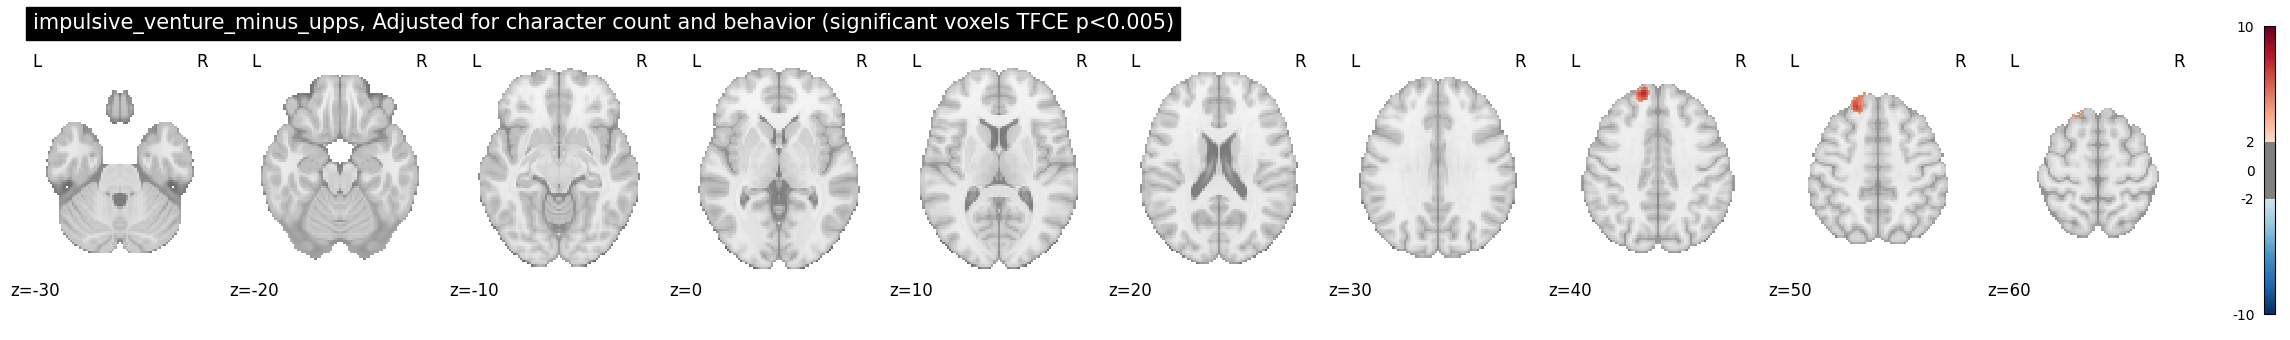

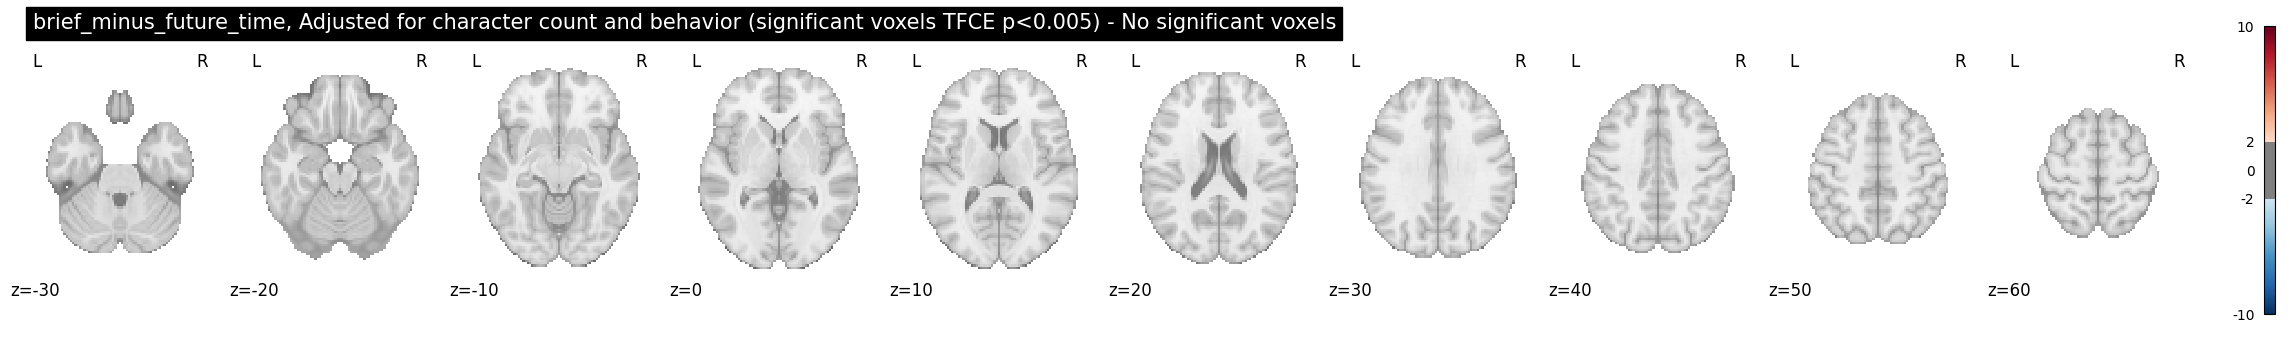

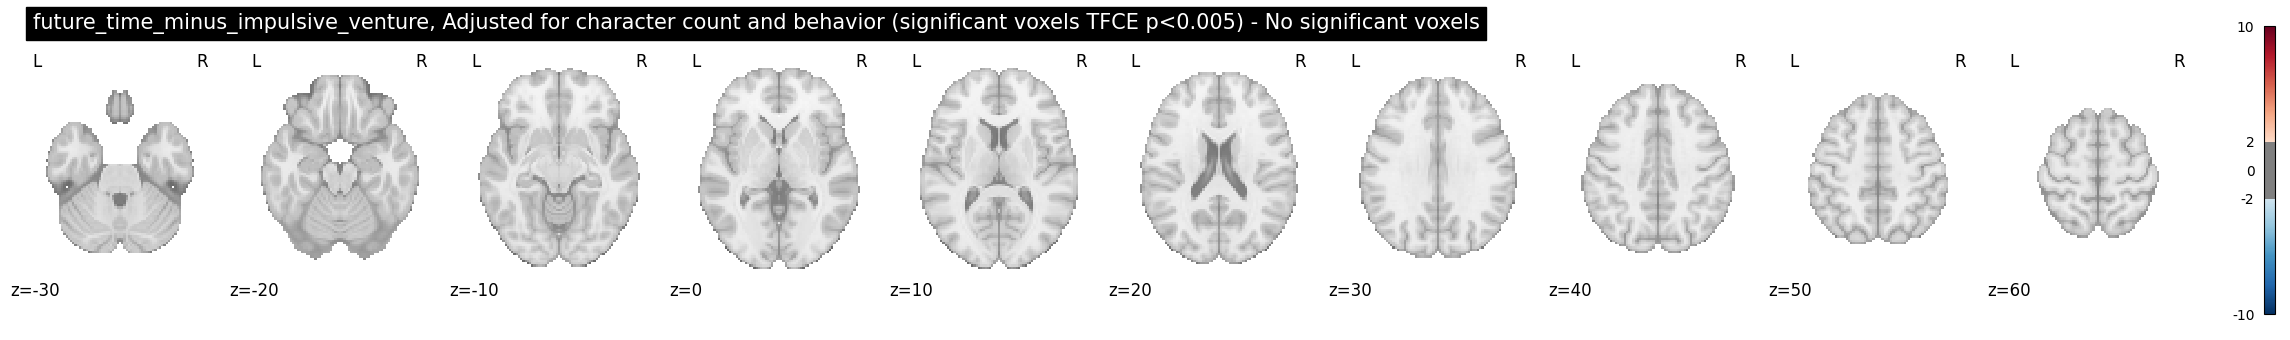

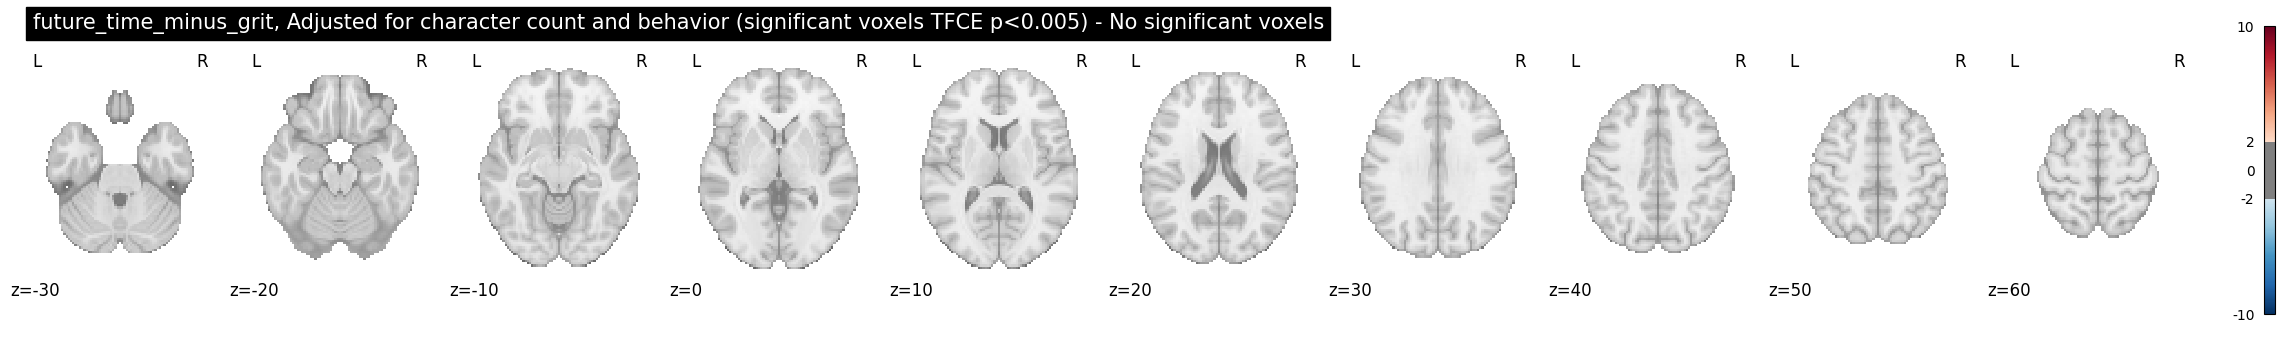

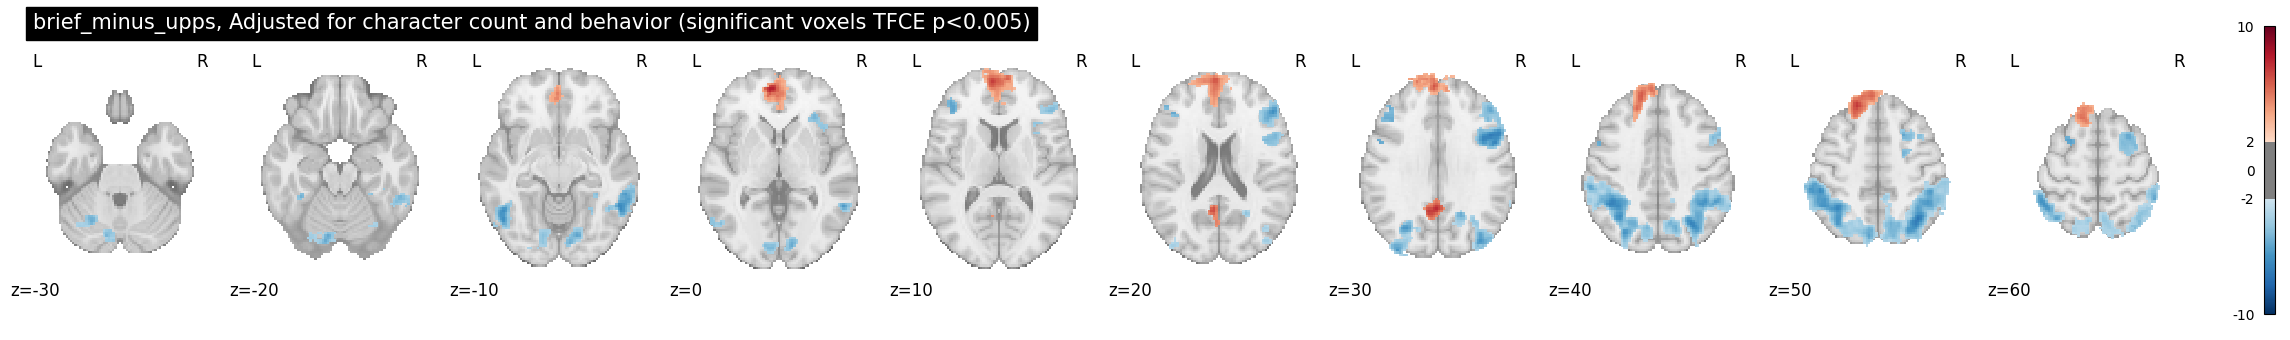

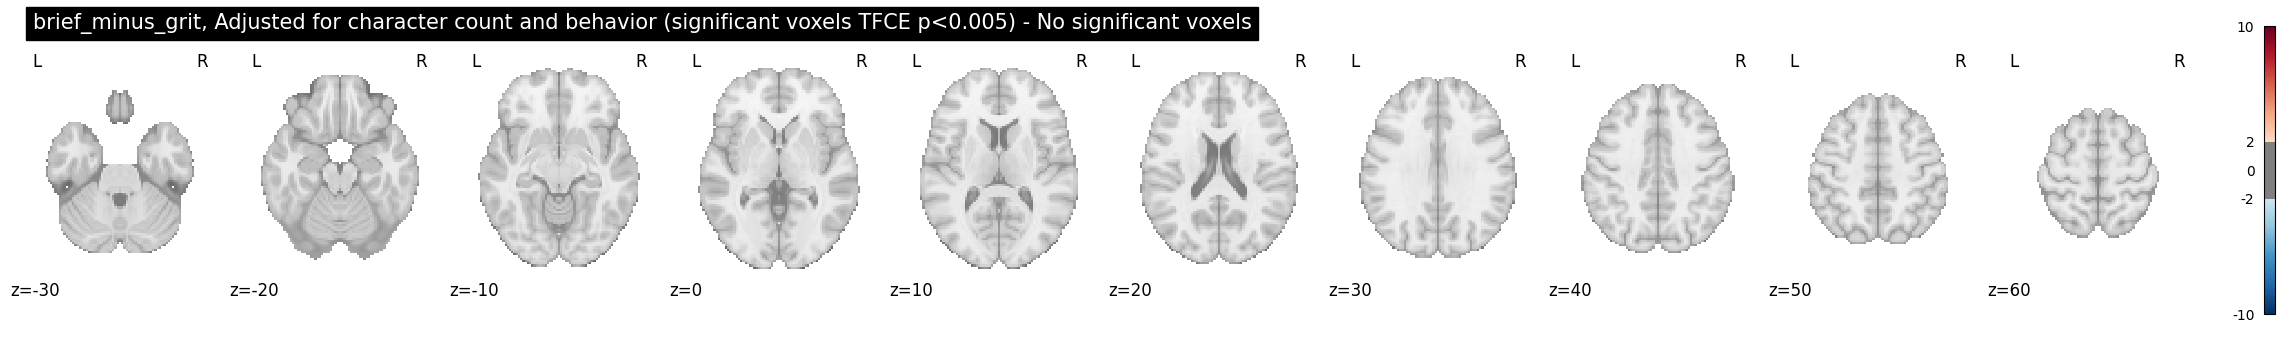

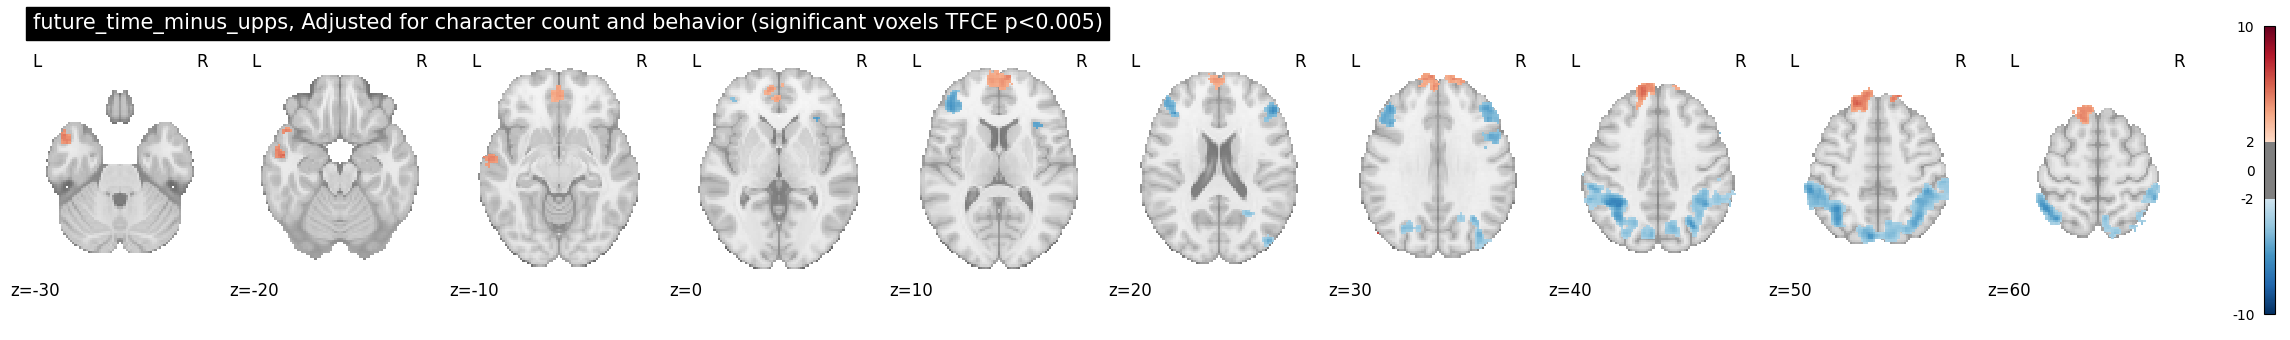

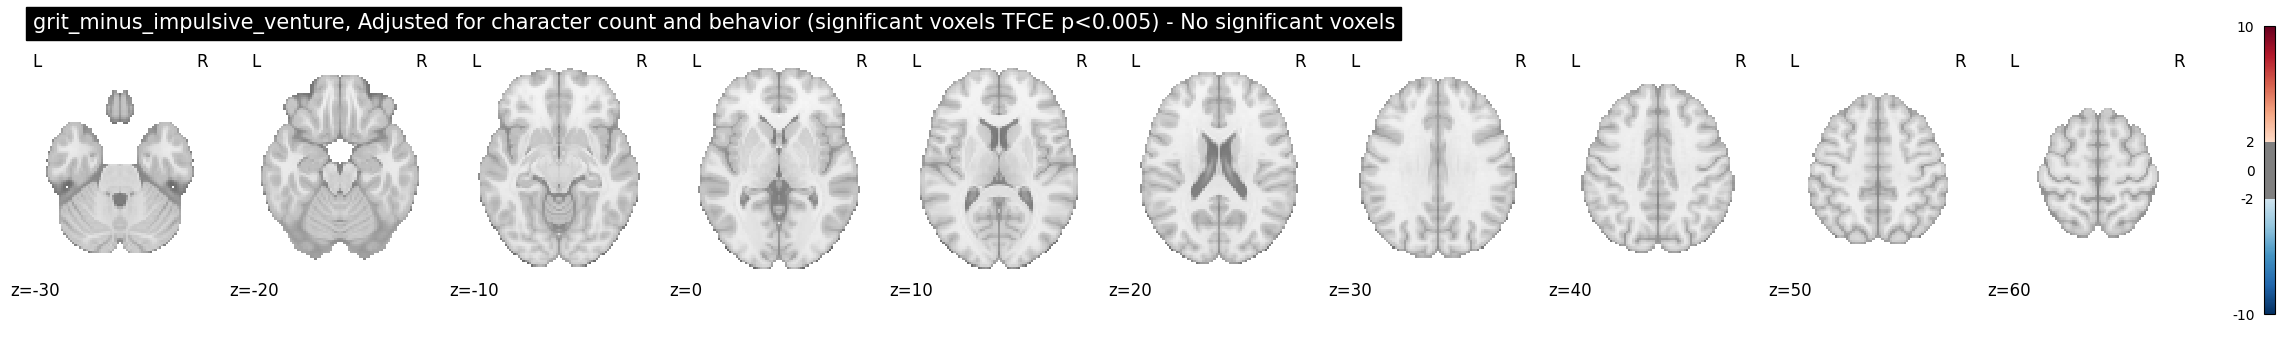

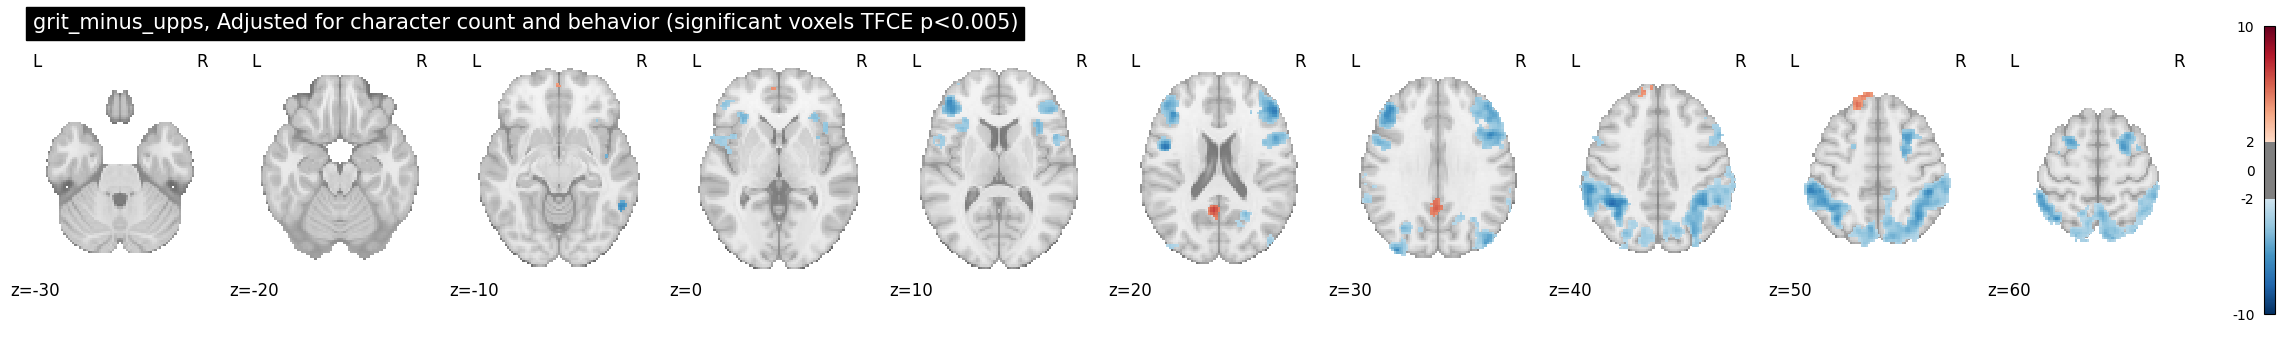

In [10]:
bon_thresh = 1 - (0.005)

z_slices = list(range(-30, 61, 10))

for map_label, map in question_pmaps.items():
    tmap = load_img(question_tmaps[map_label])
    pmap = load_img(map)
    # Threshold and binarize pmap at 0.95, then multiply by fmap
    img = math_img(f'img_t * (img_p > {bon_thresh})', img_t=tmap, img_p=pmap)

    # Check if there are any significant voxels
    img_data = get_data(img)
    has_sig_voxels = np.any(img_data != 0)

    # Prepare the title
    title = f'{map_label}, Adjusted for character count and behavior (significant voxels TFCE p<{1 - bon_thresh:.3})'
    if not has_sig_voxels:
        title += ' - No significant voxels'

    display = plot_stat_map(
        img,
        threshold=2,
        display_mode='z',
        cut_coords=z_slices,
        colorbar=True,
        title=title,
        symmetric_cbar=True,
        vmax=10,
    )
    plt.show()
    display.close()


## 3. Conjunction analysis
Compared to analyses where we did not adjust for behavior response, these results seem to mostly highlight differences with `UPPS`.  This makese sense since we had to exclude more `impulsive venture` data in this analysis since behavior could not be missing.  Additionally, the adjustment for behavior could be weakening the differences we saw with `impulsive venture` previously.

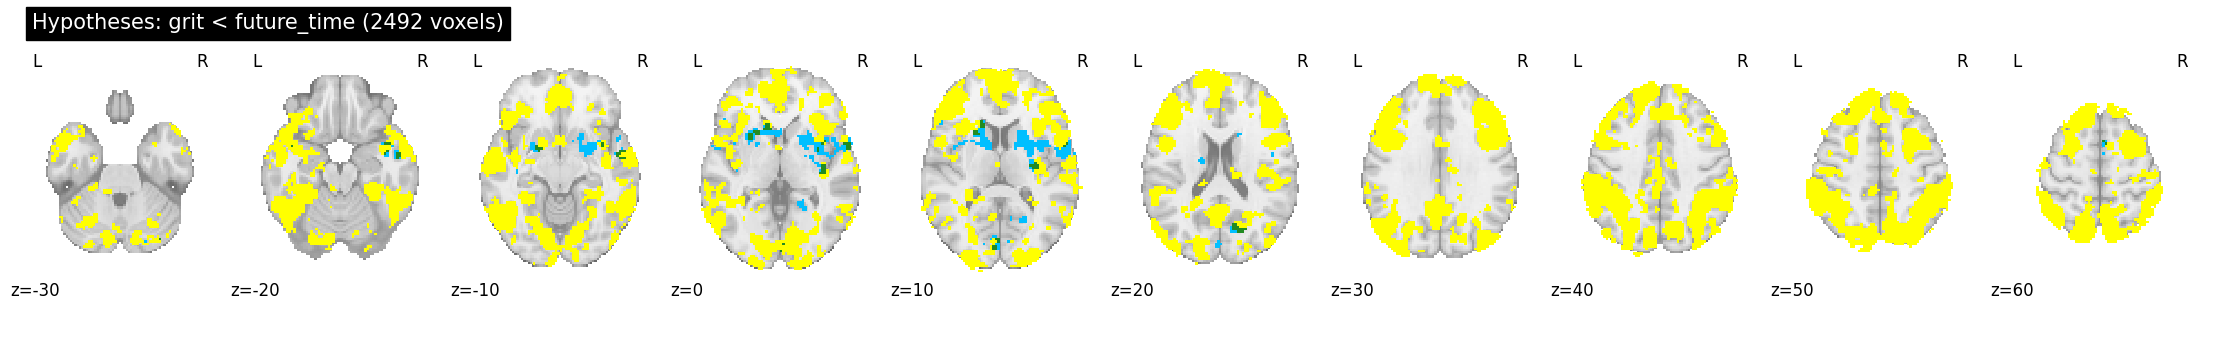

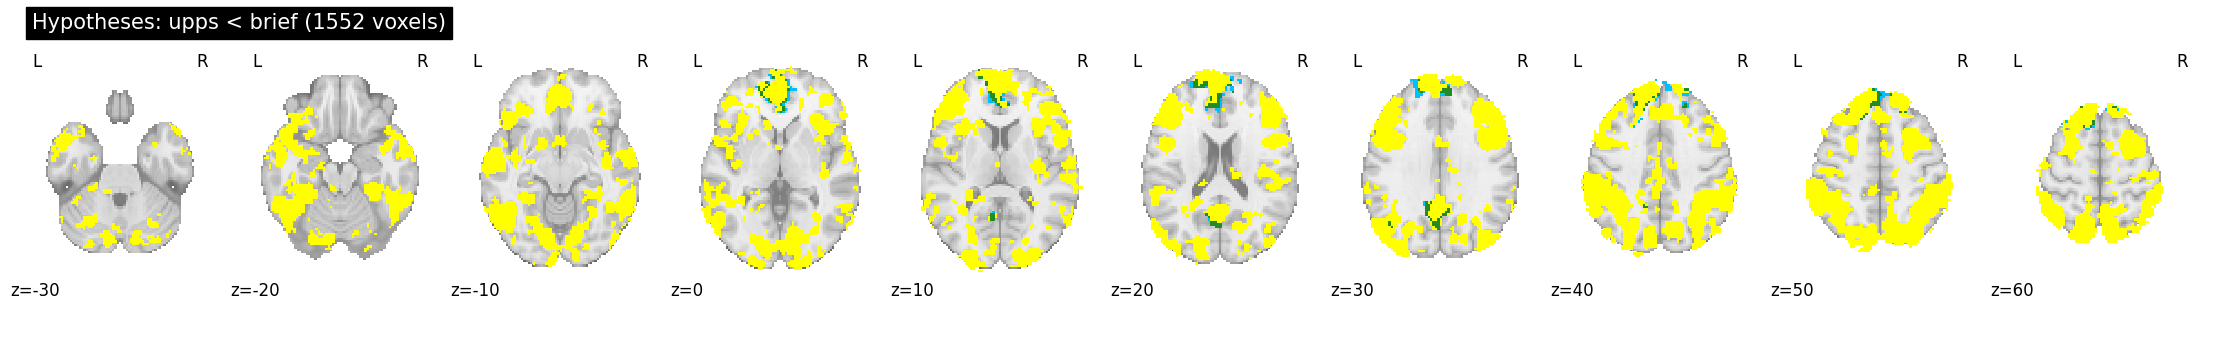

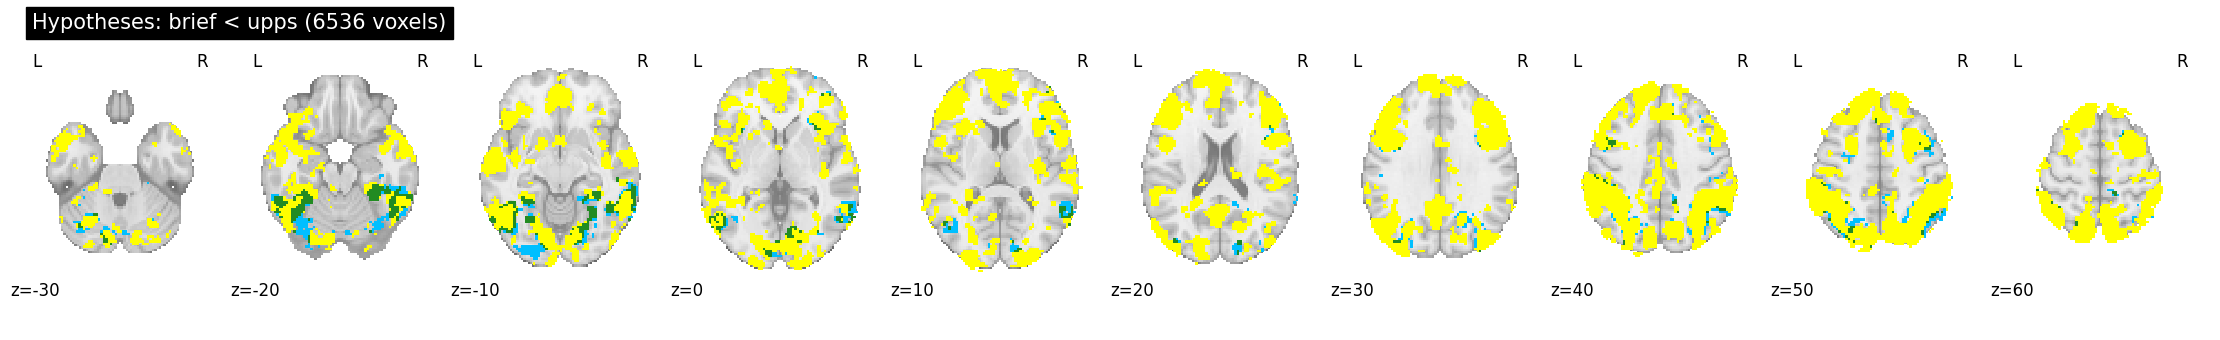

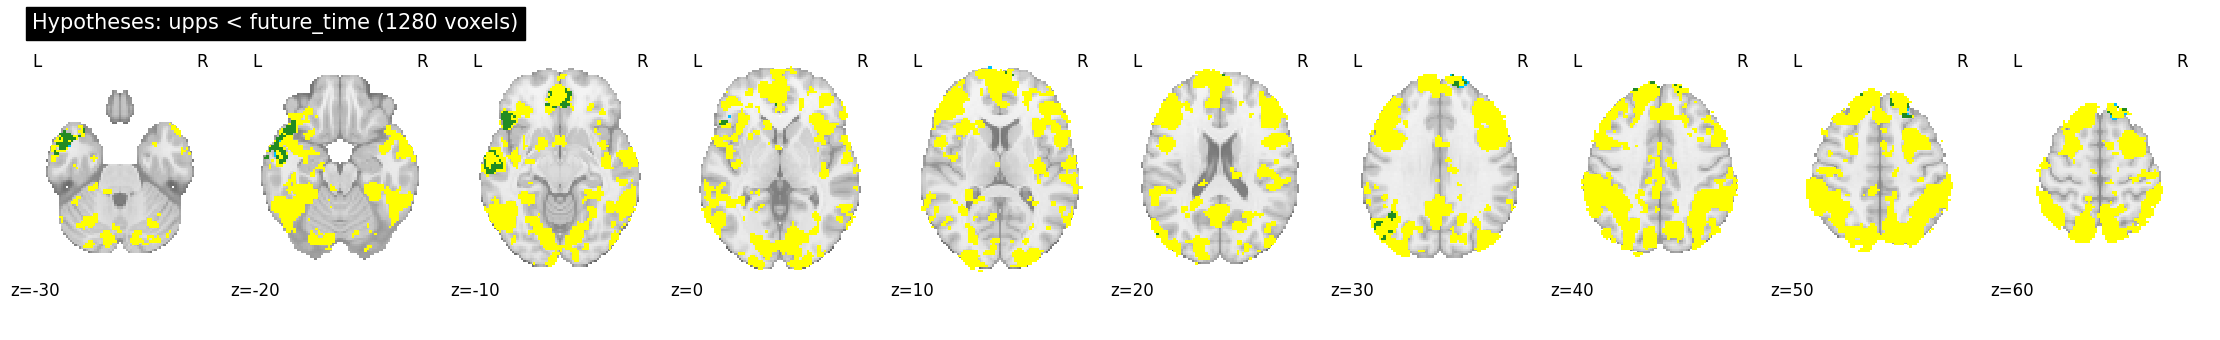

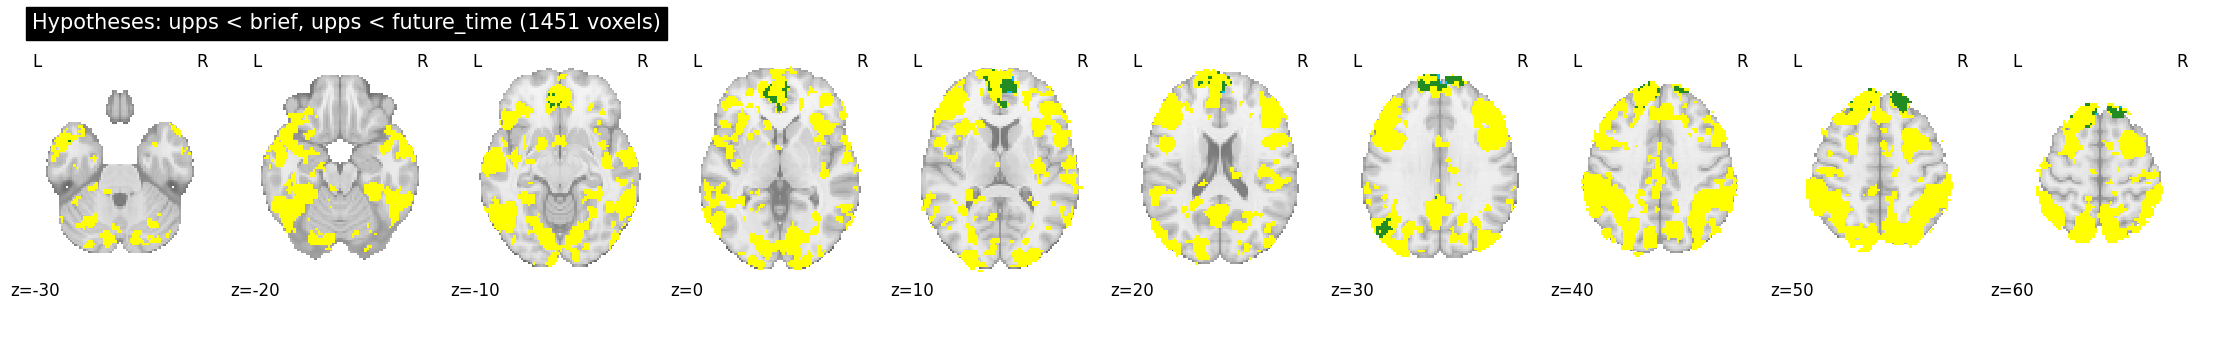

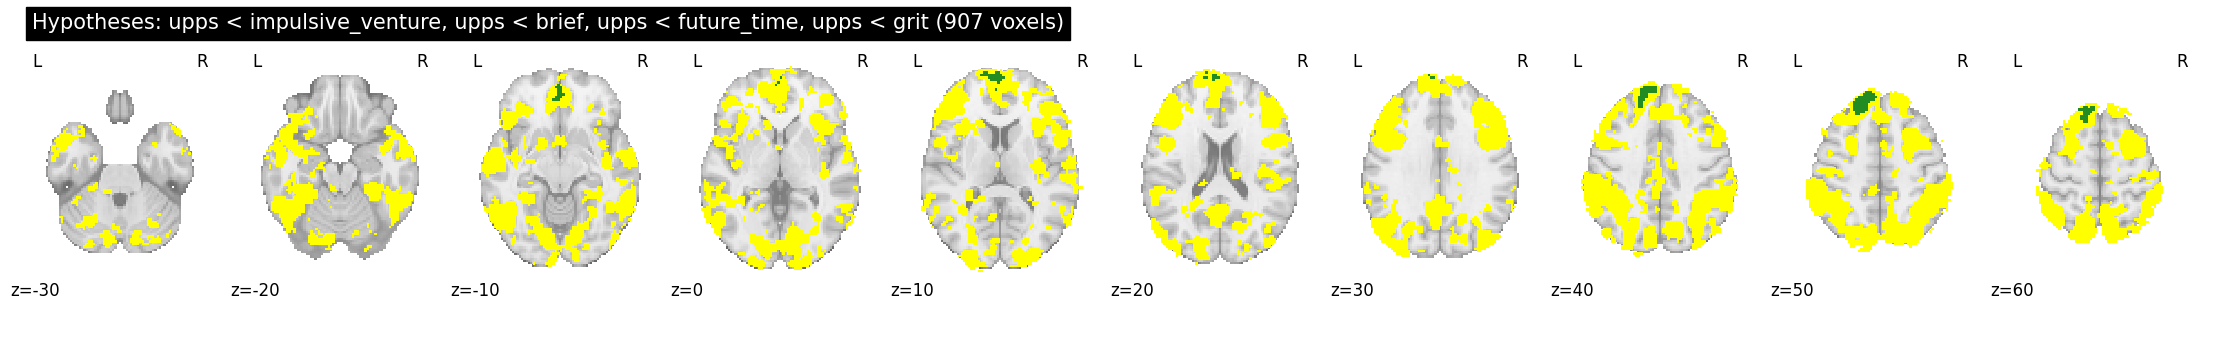

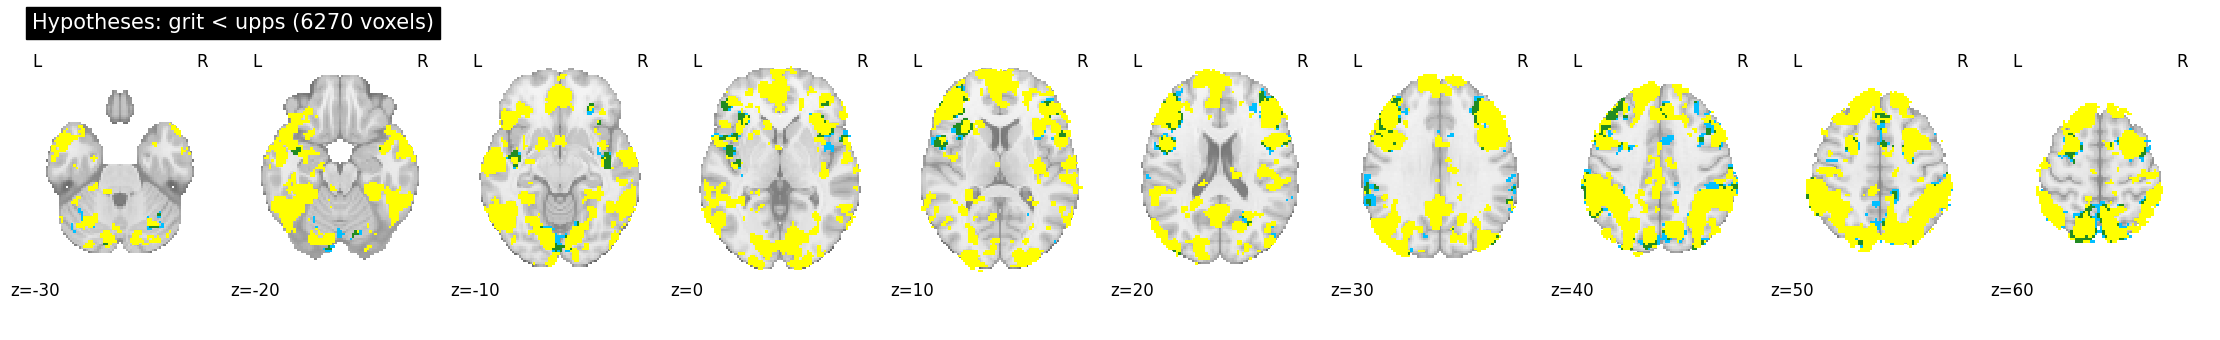

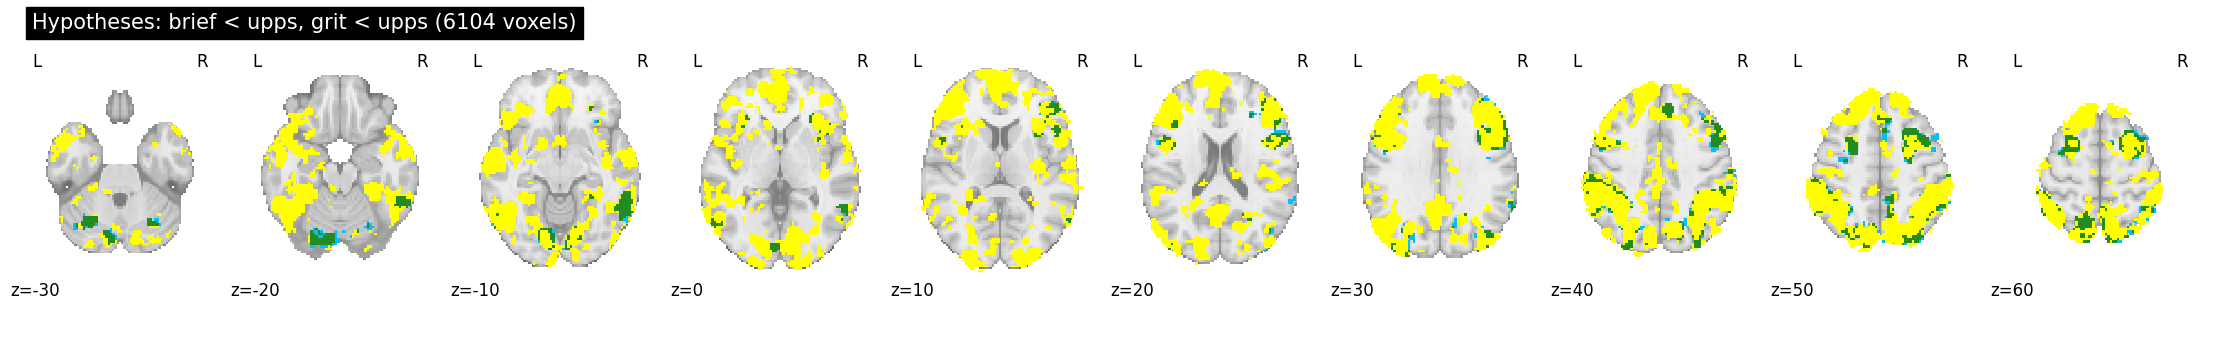

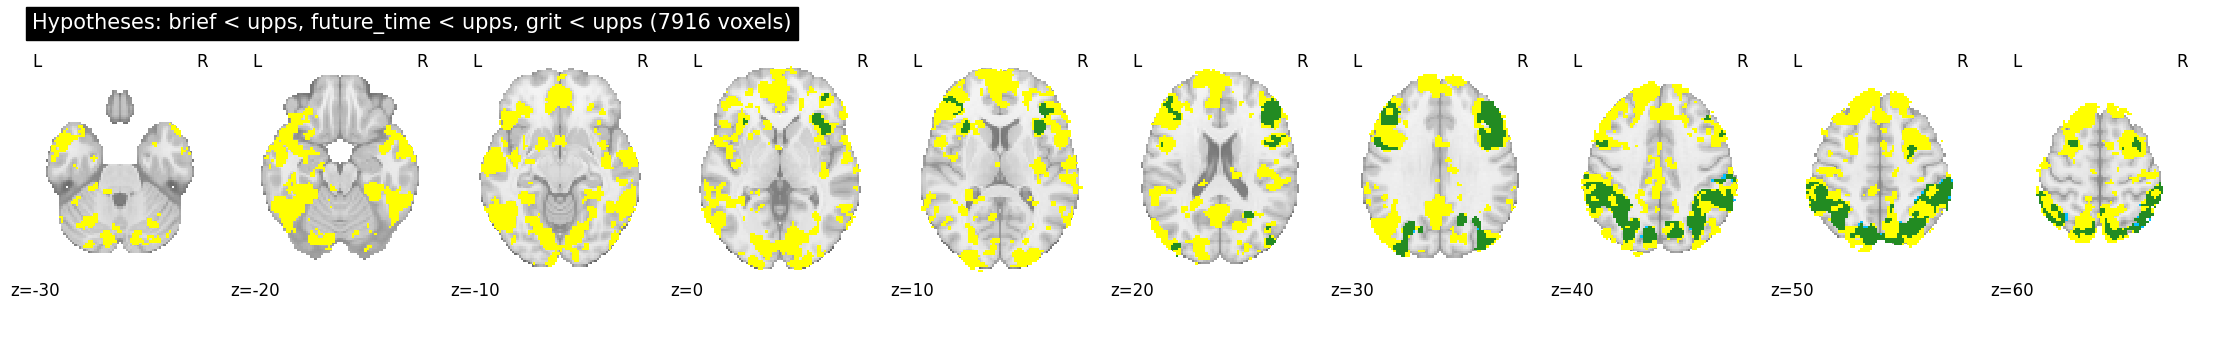

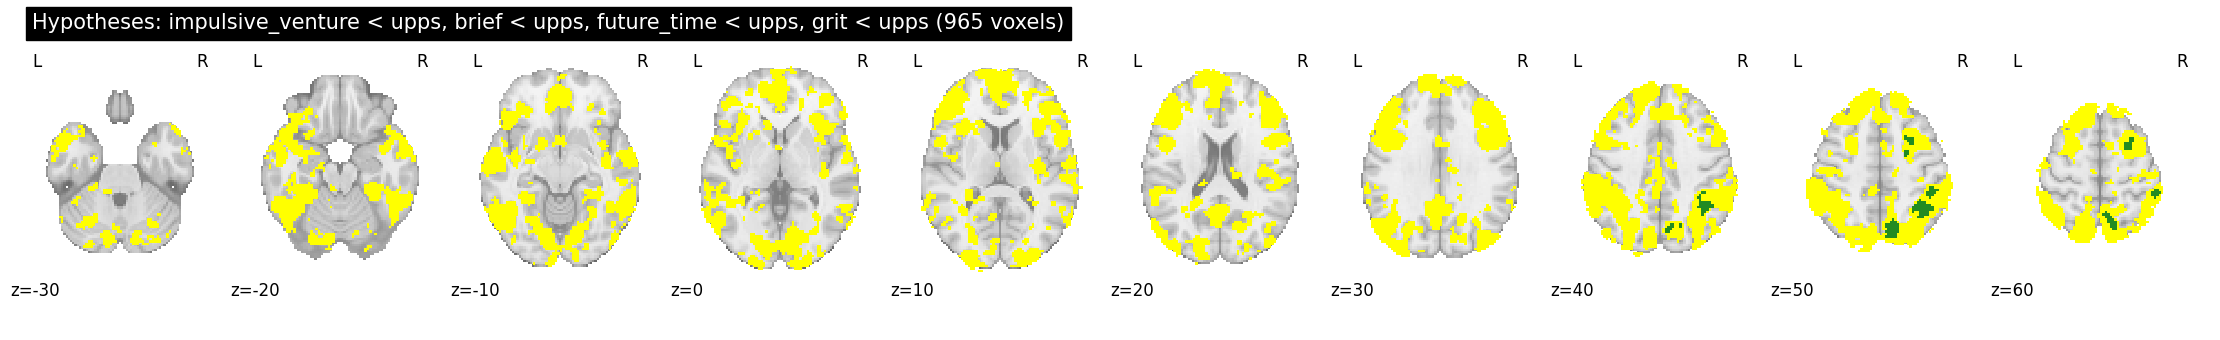

In [11]:
process_pairwise_maps(
    question_tmaps,
    question_pmaps,
    omnibus_pmap_file,
    mask_path,
    z_slices,
    t_threshold=0.05,
    omnibus_f_threshold=0.05,
    min_cluster_vox=400,
)

## Peeking at the two-sided test for the behavior slope

In [13]:
slope_t_test = outdir / 'output_twosided_onesample_t_test'

slope_p = slope_t_test / 'onesample_2sided_tfce_corrp_fstat1.nii.gz'
slope_t = slope_t_test / 'uncorrected_tstat1.nii.gz'

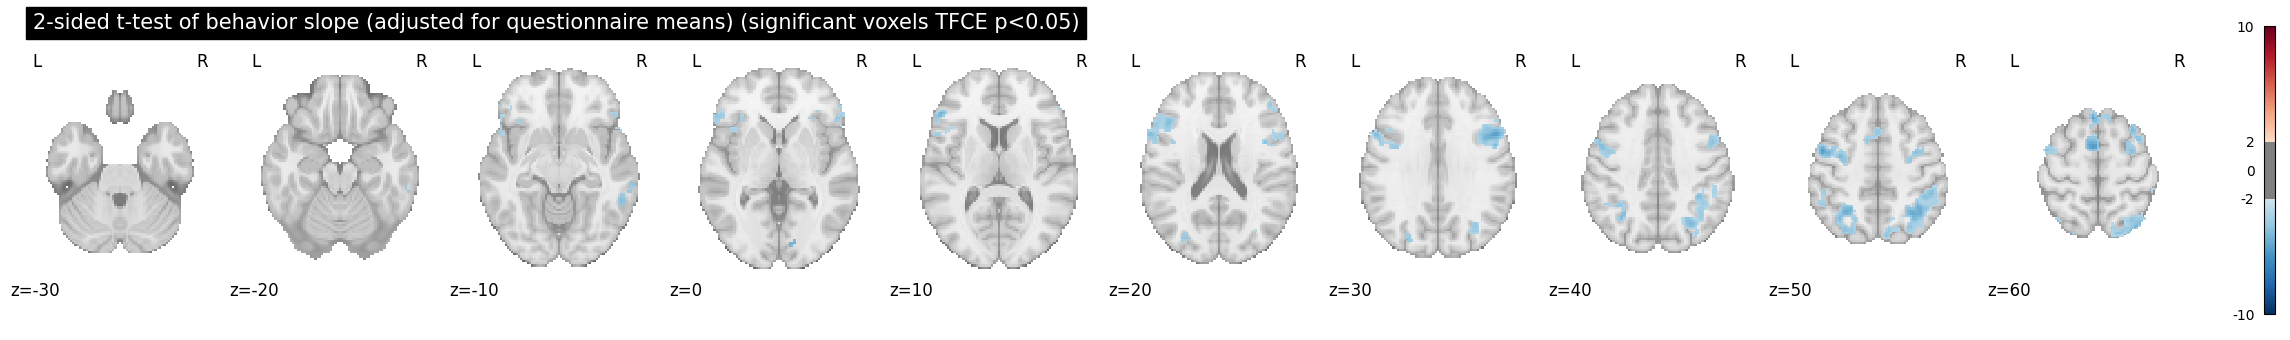

In [16]:
tmap = load_img(slope_t)
pmap = load_img(slope_p)
# Threshold and binarize pmap at 0.95, then multiply by fmap
img = math_img('img_t * (img_p > 0.95)', img_t=tmap, img_p=pmap)

# Check if there are any significant voxels
img_data = get_data(img)
has_sig_voxels = np.any(img_data != 0)

# Prepare the title
title = f'2-sided t-test of behavior slope (adjusted for questionnaire means) (significant voxels TFCE p<{1 - 0.95:.2f})'
if not has_sig_voxels:
    title += ' - No significant voxels'

display = plot_stat_map(
    img,
    threshold=2,
    display_mode='z',
    cut_coords=z_slices,
    colorbar=True,
    title=title,
    symmetric_cbar=True,
    vmax=10,
)
plt.show()
display.close()